Computing optimal transport...
Time taken for Optimal Transport: 3.623837947845459 seconds


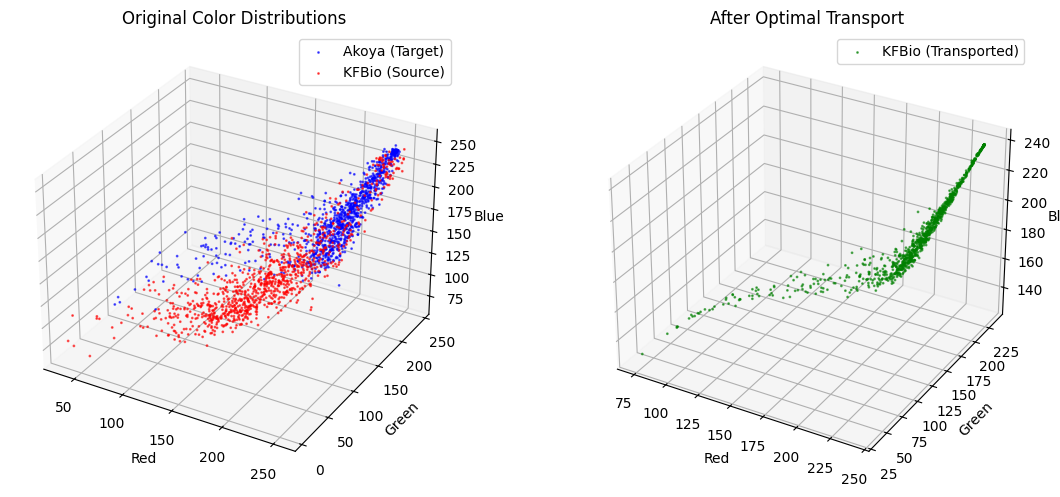

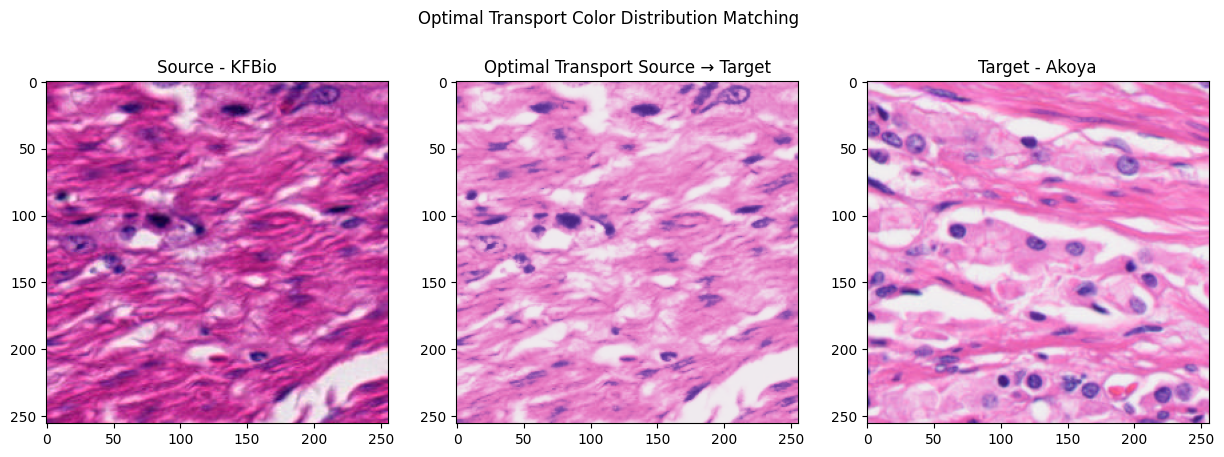

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
from scipy.optimize import linprog
from scipy.spatial.distance import cdist
import deeplake

def compute_optimal_transport_mapping(source_colors, target_colors, reg=0.01):
    """
    Compute optimal transport mapping between source and target color distributions
    using regularized optimal transport (Sinkhorn algorithm)
    """
    # Compute cost matrix (Euclidean distance between colors)
    cost_matrix = cdist(source_colors, target_colors, metric='euclidean')**2
    
    # Normalize cost matrix for numerical stability
    cost_matrix = cost_matrix / np.max(cost_matrix)
    
    # Uniform distributions
    n_source = len(source_colors)
    n_target = len(target_colors)
    a = np.ones(n_source) / n_source
    b = np.ones(n_target) / n_target
    
    # Sinkhorn iterations for regularized optimal transport
    K = np.exp(-cost_matrix / reg)
    u = np.ones(n_source) / n_source
    
    # More iterations with better convergence checking
    for iteration in range(1000):
        u_prev = u.copy()
        v = b / (K.T @ u + 1e-16)
        u = a / (K @ v + 1e-16)
        
        # Check for convergence
        if iteration > 10 and np.max(np.abs(u - u_prev)) < 1e-6:
            break
    
    # Transport plan
    transport_plan = np.diag(u) @ K @ np.diag(v)
    
    # Ensure each row sums to something positive (numerical stability)
    row_sums = transport_plan.sum(axis=1)
    zero_rows = row_sums < 1e-12
    if np.any(zero_rows):
        # For zero rows, use uniform distribution over targets
        transport_plan[zero_rows] = 1.0 / n_target
    
    return transport_plan

def apply_optimal_transport_color_matching(src_img, target_colors, num_samples=5000):
    """
    Apply optimal transport to match source image colors to target distribution
    """
    # Get image dimensions
    channels, height, width = src_img.shape
    
    # Reshape source image to (n_pixels, 3)
    src_pixels = src_img.transpose((1, 2, 0)).reshape(-1, 3).astype(np.float64)
    target_colors = target_colors.astype(np.float64)
    
    # Sample colors for optimal transport computation (for efficiency)
    if len(src_pixels) > num_samples:
        src_indices = np.random.choice(len(src_pixels), num_samples, replace=False)
        src_sample = src_pixels[src_indices]
    else:
        src_sample = src_pixels.copy()
        src_indices = np.arange(len(src_pixels))
    
    if len(target_colors) > num_samples:
        trg_indices = np.random.choice(len(target_colors), num_samples, replace=False)
        trg_sample = target_colors[trg_indices]
    else:
        trg_sample = target_colors.copy()
    
    # Compute optimal transport mapping
    transport_plan = compute_optimal_transport_mapping(src_sample, trg_sample)
    
    # Create a mapping from source colors to transported colors
    # Instead of matrix multiplication, map each source color to weighted average of targets
    transported_sample = np.zeros_like(src_sample)
    for i in range(len(src_sample)):
        # Get transport weights for this source color
        weights = transport_plan[i]
        
        # Check if weights sum is valid
        weight_sum = np.sum(weights)
        if weight_sum > 1e-12:
            # Weighted average of target colors
            transported_sample[i] = np.average(trg_sample, axis=0, weights=weights)
        else:
            # Fallback: use the closest target color
            distances = np.linalg.norm(trg_sample - src_sample[i], axis=1)
            closest_idx = np.argmin(distances)
            transported_sample[i] = trg_sample[closest_idx]
    
    # Apply the color mapping to the full image using interpolation
    result_pixels = np.zeros_like(src_pixels)
    
    # Use vectorized nearest neighbor search
    from scipy.spatial.distance import cdist
    distances = cdist(src_pixels, src_sample)
    closest_indices = np.argmin(distances, axis=1)
    result_pixels = transported_sample[closest_indices]
    
    # Ensure values are in valid range
    result_pixels = np.clip(result_pixels, 0, 255)
    
    # Reshape back to image format
    result_img = result_pixels.reshape(height, width, 3).transpose((2, 0, 1))
    
    return result_img, transported_sample

# Test - Replace your original code with this
dataset_path_akoya_1 = f"/home/leolr-int/nfs/data/data/patched/dim_256/Train/Subset3_Train_1_Akoya"
akoya_1 = deeplake.open_read_only(dataset_path_akoya_1)
dataset_path_KFbio_1 = f"/home/leolr-int/nfs/data/data/patched/dim_256/Train/Subset3_Train_1_KFBio"
KFBio_1 = deeplake.open_read_only(dataset_path_KFbio_1)
src_img = KFBio_1[200]["patch"].transpose((2, 0, 1))  # (3, 256, 256)
trg_img = akoya_1[0]["patch"].transpose((2, 0, 1))
L_hyperparam = 0.01

# Extract color distributions
src_colors = src_img.transpose((1, 2, 0)).reshape(-1, 3).astype(np.float64)  # (n_pixels, 3)
trg_colors = trg_img.transpose((1, 2, 0)).reshape(-1, 3).astype(np.float64)  # (n_pixels, 3)

# Sample for visualization and computation efficiency
n_samples_viz = 1000
src_sample_idx = np.random.choice(len(src_colors), min(n_samples_viz, len(src_colors)), replace=False)
trg_sample_idx = np.random.choice(len(trg_colors), min(n_samples_viz, len(trg_colors)), replace=False)

src_colors_viz = src_colors[src_sample_idx]
trg_colors_viz = trg_colors[trg_sample_idx]

# Plot original color distributions
fig = plt.figure(figsize=(12, 5))

# 3D scatter plot of original distributions
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(trg_colors_viz[:, 0], trg_colors_viz[:, 1], trg_colors_viz[:, 2], 
           c='blue', alpha=0.6, s=1, label='Akoya (Target)')
ax1.scatter(src_colors_viz[:, 0], src_colors_viz[:, 1], src_colors_viz[:, 2], 
           c='red', alpha=0.6, s=1, label='KFBio (Source)')
ax1.set_xlabel('Red')
ax1.set_ylabel('Green')
ax1.set_zlabel('Blue')
ax1.set_title('Original Color Distributions')
ax1.legend()

# Apply optimal transport
print("Computing optimal transport...")
start_time = time.time()
ot_result_img, transported_colors = apply_optimal_transport_color_matching(src_img, trg_colors, num_samples=2000)
end_time = time.time()
print(f"Time taken for Optimal Transport: {end_time - start_time} seconds")

# Sample transported colors for visualization
transported_sample_idx = np.random.choice(len(transported_colors), min(n_samples_viz, len(transported_colors)), replace=False)
transported_colors_viz = transported_colors[transported_sample_idx]

# 3D scatter plot with transported colors
ax2 = fig.add_subplot(122, projection='3d')
#ax2.scatter(trg_colors_viz[:, 0], trg_colors_viz[:, 1], trg_colors_viz[:, 2], c='blue', alpha=0.6, s=1, label='Akoya (Target)')
#ax2.scatter(src_colors_viz[:, 0], src_colors_viz[:, 1], src_colors_viz[:, 2], c='red', alpha=0.6, s=1, label='KFBio (Original)')
ax2.scatter(transported_colors_viz[:, 0], transported_colors_viz[:, 1], transported_colors_viz[:, 2], c='green', alpha=0.6, s=1, label='KFBio (Transported)')
ax2.set_xlabel('Red')
ax2.set_ylabel('Green')
ax2.set_zlabel('Blue')
ax2.set_title('After Optimal Transport')
ax2.legend()

plt.tight_layout()
#plt.savefig(f"/home/leolr-int/nfs/ASTAR_internship/Fourier_Domain_Adaptation/images/color_distributions_3d.png")
plt.show()

# Display images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(src_img.transpose((1, 2, 0)).astype(np.uint8))
axes[0].set_title("Source - KFBio")
axes[1].imshow(np.clip(ot_result_img.transpose((1, 2, 0)), 0, 255).astype(np.uint8))
axes[1].set_title("Optimal Transport Source → Target")
axes[2].imshow(trg_img.transpose((1, 2, 0)).astype(np.uint8))
axes[2].set_title("Target - Akoya")
plt.suptitle("Optimal Transport Color Distribution Matching")
#plt.savefig(f"/home/leolr-int/nfs/ASTAR_internship/Fourier_Domain_Adaptation/images/optimal_transport_result.png")
plt.show()

what if i compute the average of 3D color vectors for each patch for each label and approximate it with a gaussian kernel and then i apply optimal transport on each pixel of the input patch?